본인 계정에서 셀 실행하려면 공유드라이브에 있는 rtu_data_full2 파일 점 3개 클릭-> 정리-> 바로가기 추가-> 내 드라이브
후 실행하면됨(코랩프로기준 3번 셀 실행가능함)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/rtu_data_full2")

NameError: name 'pd' is not defined

In [ ]:
# 데이터셋 확인용
# 1. 데이터 기본 정보 및 결측치 확인
print("=== DATA INFO ===")
print(df.info())

# 2. 수치형 데이터의 기초 통계량 (이상치 파악용)
print("\n=== DESCRIBE ===")
print(df.describe())

# 3. 데이터 실제 샘플 3줄 보기
print("\n=== HEAD SAMPLE ===")
print(df.head(3).to_markdown())

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33696013 entries, 0 to 33696012
Data columns (total 19 columns):
 #   Column                Dtype  
---  ------                -----  
 0   module(equipment)     object 
 1   timestamp             int64  
 2   localtime             int64  
 3   operation             int64  
 4   voltageR              float64
 5   voltageS              float64
 6   voltageT              float64
 7   voltageRS             float64
 8   voltageST             float64
 9   voltageTR             float64
 10  currentR              float64
 11  currentS              float64
 12  currentT              float64
 13  activePower           float64
 14  powerFactorR          float64
 15  powerFactorS          float64
 16  powerFactorT          float64
 17  reactivePowerLagging  float64
 18  accumActiveEnergy     int64  
dtypes: float64(14), int64(4), object(1)
memory usage: 4.8+ GB
None

=== DESCRIBE ===
          timestamp     localtime   operation 

데이터 개요

*   데이터센터 rtu 전력 데이터
19 개 칼럼, 설비 13종, 20241201~20250430(150일 정도), 5초 간격으로 수집


In [ ]:
# 전처리 준비 1)
RAW_PATH = "/content/drive/MyDrive/rtu_data_full.csv"
OUTPUT_DIR = "/content/drive/MyDrive/processed/"

# 전압/전류 물리적 정상 범위 (설비 정격 기준 - 실제 스펙 확인 후 조정)
VOLTAGE_PHASE_RANGE = (150, 250)   # voltageR/S/T
VOLTAGE_LINE_RANGE = (300, 420)    # voltageRS/ST/TR
CURRENT_RANGE = (0, 100)
POWER_FACTOR_RANGE = (0, 100)

# 피크시간대 10시 전후 가정
PEAK_HOURS = list(range(21, 24)) + [0]

In [ ]:
# 전처리 준비 2)
df = pd.read_csv(RAW_PATH)

print("=== 기본 정보 ===")
print(f"행 수: {len(df):,}")
print(f"메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
print(f"설비 종류: {df['module(equipment)'].unique()}")
print(f"operation 값 분포:\n{df['operation'].value_counts()}")

# dtype 다운캐스팅(float64 -> float32)으로 메모리 절약
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype('float32')
gc.collect()

df['datetime'] = pd.to_datetime(df['localtime'].astype(str), format='%Y%m%d%H%M%S')

=== 기본 정보 ===
행 수: 33,696,013
메모리 사용량: 7.04 GB
설비 종류: ['1(PM-3)' '2(L-1전등)' '3(분쇄기(2))' '4(분쇄기(1))' '5(좌측분전반)' '11(우측분전반1)'
 '12(4호기)' '13(3호기)' '14(2호기)' '15(예비건조기)' '16(호이스트)' '17(6호기)'
 '18(우측분전반2)']
operation 값 분포:
operation
1    33696013
Name: count, dtype: int64


In [ ]:
# 전처리 3) 설비별 수집 공백 체크
gap_reports = []
for eq, g in df.groupby('module(equipment)'):
    g = g.sort_values('datetime')
    diffs = g['datetime'].diff().dt.total_seconds()
    gap_reports.append({
        'equipment': eq,
        'rows': len(g),
        'gap_count_over_7_5s': (diffs > 7.5).sum(),
        'max_gap_sec': diffs.max(),
        'start': g['datetime'].min(),
        'end': g['datetime'].max(),
    })

gap_report_df = pd.DataFrame(gap_reports)
print("=== 설비별 수집 공백 리포트 ===")
print(gap_report_df)

del gap_reports
gc.collect()

=== 설비별 수집 공백 리포트 ===
     equipment     rows  gap_count_over_7_5s  max_gap_sec      start  \
0      1(PM-3)  2592001                    0          5.0 2024-12-01   
1   11(우측분전반1)  2592001                    0          5.0 2024-12-01   
2      12(4호기)  2592001                    0          5.0 2024-12-01   
3      13(3호기)  2592001                    0          5.0 2024-12-01   
4      14(2호기)  2592001                    0          5.0 2024-12-01   
5    15(예비건조기)  2592001                    0          5.0 2024-12-01   
6     16(호이스트)  2592001                    0          5.0 2024-12-01   
7      17(6호기)  2592001                    0          5.0 2024-12-01   
8   18(우측분전반2)  2592001                    0          5.0 2024-12-01   
9     2(L-1전등)  2592001                    0          5.0 2024-12-01   
10   3(분쇄기(2))  2592001                    0          5.0 2024-12-01   
11   4(분쇄기(1))  2592001                    0          5.0 2024-12-01   
12    5(좌측분전반)  2592001                   

53

In [ ]:
# 전처리 4) 정렬 및 결측치 처리(시간보간)
df = df.sort_values(['module(equipment)', 'datetime']).reset_index(drop=True)

print("=== 결측치 현황 (처리 전) ===")
print(df.isna().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['timestamp', 'localtime', 'operation']]

# 설비별 선형 보간, 30초(6개 포인트) 공백까지만 채움
df[numeric_cols] = (
    df.groupby('module(equipment)')[numeric_cols]
      .transform(lambda x: x.interpolate(method='linear', limit=6))
)

print(f"보간 후 남은 결측치: {df[numeric_cols].isna().sum().sum()}")
gc.collect()


=== 결측치 현황 (처리 전) ===
module(equipment)       0
timestamp               0
localtime               0
operation               0
voltageR                0
voltageS                0
voltageT                0
voltageRS               0
voltageST               0
voltageTR               0
currentR                0
currentS                0
currentT                0
activePower             0
powerFactorR            0
powerFactorS            0
powerFactorT            0
reactivePowerLagging    0
accumActiveEnergy       0
datetime                0
dtype: int64
보간 후 남은 결측치: 0


0

In [ ]:
# 전처리 5-1) 물리적 범위 이탈-전압만
conditions = []
for col in ['voltageR', 'voltageS', 'voltageT']:
    conditions.append(~df[col].between(*VOLTAGE_PHASE_RANGE))
for col in ['voltageRS', 'voltageST', 'voltageTR']:
    conditions.append(~df[col].between(*VOLTAGE_LINE_RANGE))

df['is_physical_outlier'] = np.logical_or.reduce(conditions)
print(f"전압 범위 이탈 행: {df['is_physical_outlier'].sum():,} ({df['is_physical_outlier'].mean():.4%})")
del conditions
gc.collect()

# 5-2. 통계적 이상치 - 설비별 IQR (전류/전력은 설비마다 다른 스케일이므로)
stat_check_cols = ['activePower', 'currentR', 'currentS', 'currentT',
                    'powerFactorR', 'powerFactorS', 'powerFactorT']
flags = pd.Series(False, index=df.index)

for eq, g in df.groupby('module(equipment)'):
    for col in stat_check_cols:
        q1, q3 = g[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 3.0 * iqr, q3 + 3.0 * iqr
        flags.loc[g.index] |= ~g[col].between(lower, upper)

df['is_statistical_outlier'] = flags
print(f"통계적 이상치(IQR, 설비별) 행: {flags.sum():,} ({flags.mean():.4%})")

# 설비별 이상치 비율도 따로 확인 (특정 설비에 몰려있는지 체크)
print("=== 설비별 통계적 이상치 비율 ===")
print(df.groupby('module(equipment)').apply(lambda g: flags.loc[g.index].mean()))

del flags
gc.collect()

전압 범위 이탈 행: 0 (0.0000%)
통계적 이상치(IQR, 설비별) 행: 20,317 (0.0603%)
=== 설비별 통계적 이상치 비율 ===
module(equipment)
1(PM-3)       0.000000
11(우측분전반1)    0.000000
12(4호기)       0.000000
13(3호기)       0.000000
14(2호기)       0.000000
15(예비건조기)     0.007838
16(호이스트)      0.000000
17(6호기)       0.000000
18(우측분전반2)    0.000000
2(L-1전등)      0.000000
3(분쇄기(2))     0.000000
4(분쇄기(1))     0.000000
5(좌측분전반)      0.000000
dtype: float64


/tmp/ipykernel_1108/1241205354.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('module(equipment)').apply(lambda g: flags.loc[g.index].mean()))


0

In [ ]:
# 추가 전처리  5-1) 예비건조기(15)만 진단 - 이상치가 왜 여기 몰렸는지 확인

target_eq = '15(예비건조기)'
sub = df[df['module(equipment)'] == target_eq]

print(f"=== {target_eq} 기본 통계 ===")
print(sub[['activePower', 'currentR', 'currentS', 'currentT',
           'powerFactorR', 'powerFactorS', 'powerFactorT']].describe())

print(f"\noperation 값 분포:\n{sub['operation'].value_counts()}")

# activePower가 0 근처(대기/정지)인 비율 확인 - '예비' 설비 특성상 대부분 유휴 상태일 가능성
idle_threshold = sub['activePower'].quantile(0.5)  # 중위값 기준 참고용
print(f"\nactivePower 중위값: {idle_threshold:.2f}")
print(f"activePower < 100 (거의 유휴로 추정) 비율: {(sub['activePower'] < 100).mean():.4%}")

# 이상치로 잡힌 행들만 따로 떼서 activePower 분포 비교
outlier_rows = sub[sub['is_statistical_outlier']]
normal_rows = sub[~sub['is_statistical_outlier']]

print(f"\n[이상치로 flag된 행] activePower 통계:")
print(outlier_rows['activePower'].describe())
print(f"\n[정상 flag 행] activePower 통계:")
print(normal_rows['activePower'].describe())

# 이상치 발생이 특정 시간대/날짜에 몰려있는지 확인 (간헐적 가동 패턴인지)
print(f"\n이상치 발생 시각 분포 (상위 10개 hour):")
print(outlier_rows['datetime'].dt.hour.value_counts().head(10))

print(f"\n이상치 발생 날짜 수: {outlier_rows['datetime'].dt.date.nunique()}일 / 전체 {sub['datetime'].dt.date.nunique()}일 중")

del sub, outlier_rows, normal_rows
gc.collect()


=== 15(예비건조기) 기본 통계 ===
        activePower      currentR      currentS      currentT  powerFactorR  \
count  2.592001e+06  2.592001e+06  2.592001e+06  2.592001e+06  2.592001e+06   
mean   3.010408e+03  1.750714e+01  1.749954e+01  1.750062e+01  9.224276e+01   
std    7.163102e+02  7.209462e+00  7.214520e+00  7.210732e+00  4.999497e+00   
min    8.781100e+02  5.000000e+00  5.000000e+00  5.000000e+00  6.000000e+01   
25%    2.504090e+03  1.126000e+01  1.124000e+01  1.125000e+01  8.863000e+01   
50%    3.010280e+03  1.751000e+01  1.750000e+01  1.751000e+01  9.242000e+01   
75%    3.515990e+03  2.375000e+01  2.375000e+01  2.375000e+01  9.621000e+01   
max    5.213060e+03  3.000000e+01  3.000000e+01  3.000000e+01  1.000000e+02   

       powerFactorS  powerFactorT  
count  2.592001e+06  2.592001e+06  
mean   9.224585e+01  9.225477e+01  
std    4.998157e+00  4.999782e+00  
min    6.000000e+01  6.000000e+01  
25%    8.863000e+01  8.864000e+01  
50%    9.243000e+01  9.244000e+01  
75%    9.621

61

In [ ]:
# 전처리 5-2) 예비건조기 이상치 - 어느 컬럼이 트리거인지 컬럼별 분해

sub2 = df[df['module(equipment)'] == target_eq]
stat_check_cols = ['activePower', 'currentR', 'currentS', 'currentT',
                    'powerFactorR', 'powerFactorS', 'powerFactorT']

print(f"=== {target_eq} 컬럼별 개별 이상치 비율 (다른 컬럼과 무관하게 단독 체크) ===")
for col in stat_check_cols:
    q1, q3 = sub2[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 3.0 * iqr, q3 + 3.0 * iqr
    col_outlier = ~sub2[col].between(lower, upper)
    print(f"{col:20s}: {col_outlier.sum():6,}건 ({col_outlier.mean():.4%})  "
          f"[정상범위: {lower:.2f} ~ {upper:.2f}]")

del sub2
gc.collect()


=== 15(예비건조기) 컬럼별 개별 이상치 비율 (다른 컬럼과 무관하게 단독 체크) ===
activePower         :      0건 (0.0000%)  [정상범위: -531.61 ~ 6551.69]
currentR            :      0건 (0.0000%)  [정상범위: -26.21 ~ 61.22]
currentS            :      0건 (0.0000%)  [정상범위: -26.29 ~ 61.28]
currentT            :      0건 (0.0000%)  [정상범위: -26.25 ~ 61.25]
powerFactorR        : 10,235건 (0.3949%)  [정상범위: 65.89 ~ 118.95]
powerFactorS        : 10,345건 (0.3991%)  [정상범위: 65.89 ~ 118.95]
powerFactorT        : 10,359건 (0.3997%)  [정상범위: 65.90 ~ 118.96]


0

In [ ]:
# 전처리 6) 파생 변수 생성

df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek  # 0=월
df['is_weekend'] = df['dayofweek'].isin([5, 6])
df['is_peak'] = df['hour'].isin(PEAK_HOURS)

voltage_cols = ['voltageR', 'voltageS', 'voltageT']
current_cols = ['currentR', 'currentS', 'currentT']
pf_cols = ['powerFactorR', 'powerFactorS', 'powerFactorT']

df['voltage_unbalance_pct'] = (
    (df[voltage_cols].max(axis=1) - df[voltage_cols].min(axis=1))
    / df[voltage_cols].mean(axis=1) * 100
)
df['current_unbalance_pct'] = (
    (df[current_cols].max(axis=1) - df[current_cols].min(axis=1))
    / df[current_cols].mean(axis=1).replace(0, np.nan) * 100
)
df['powerfactor_avg'] = df[pf_cols].mean(axis=1)

# 무효전력 비율 (비효율 proxy 후보)
df['reactive_to_active_ratio'] = (
    df['reactivePowerLagging'] / df['activePower'].replace(0, np.nan)
)

# 누적에너지 증분 (5초 단위 delta) - 계량기 롤오버로 음수 가능 -> NaN 처리
df['energy_delta'] = df.groupby('module(equipment)')['accumActiveEnergy'].diff()
neg_count = (df['energy_delta'] < 0).sum()
print(f"음수 energy_delta(계량기 롤오버 의심): {neg_count}")
df.loc[df['energy_delta'] < 0, 'energy_delta'] = np.nan

gc.collect()


In [ ]:
# 전처리 7) EDA용 리샘플 데이터 생성 (1분/5분)

agg_cols = {
    'activePower': 'mean',
    'reactivePowerLagging': 'mean',
    'powerfactor_avg': 'mean',
    'voltage_unbalance_pct': 'mean',
    'current_unbalance_pct': 'mean',
    'reactive_to_active_ratio': 'mean',
    'energy_delta': 'sum',
    'is_physical_outlier': 'sum',
    'is_statistical_outlier': 'sum',
}

df_1min = (
    df.set_index('datetime')
      .groupby('module(equipment)')
      .resample('1min')
      .agg(agg_cols)
      .reset_index()
)

df_5min = (
    df.set_index('datetime')
      .groupby('module(equipment)')
      .resample('5min')
      .agg(agg_cols)
      .reset_index()
)

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

df.to_parquet(f"{OUTPUT_DIR}rtu_processed_full.parquet", index=False)
df_1min.to_parquet(f"{OUTPUT_DIR}rtu_resampled_1min.parquet", index=False)
df_5min.to_parquet(f"{OUTPUT_DIR}rtu_resampled_5min.parquet", index=False)

print("전처리 완료. 저장 경로:", OUTPUT_DIR)
print(f"최종 df shape: {df.shape}")

gc.collect()

전처리 완료. 저장 경로: /content/drive/MyDrive/processed/
최종 df shape: (33696013, 31)


0

In [ ]:
check = pd.read_parquet(f"{OUTPUT_DIR}rtu_resampled_5min.parquet")
print(check.shape)
print(check.head())

(561613, 11)
  module(equipment)            datetime  activePower  reactivePowerLagging  \
0           1(PM-3) 2024-12-01 00:00:00  2798.143555            555.060181   
1           1(PM-3) 2024-12-01 00:05:00  3006.110352            583.110657   
2           1(PM-3) 2024-12-01 00:10:00  2997.653809            605.739319   
3           1(PM-3) 2024-12-01 00:15:00  3114.100830            641.555847   
4           1(PM-3) 2024-12-01 00:20:00  2974.752441            584.927002   

   powerfactor_avg  voltage_unbalance_pct  current_unbalance_pct  \
0        92.634392               2.122951              80.597221   
1        92.328384               2.256705              67.927383   
2        92.626945               2.376197              82.273102   
3        92.307274               2.284990              70.471474   
4        92.280273               2.325299              67.716484   

   reactive_to_active_ratio  energy_delta  is_physical_outlier  \
0                  0.197870         229.0  

< 전처리 결과>  



1.   결측  

시간축 결측은 0건(150일동안 5초간격으로 측정하는 동안 한번도 끊긴 적 없이 측정됨), 값 결측치 0건, 계량기 롤오버(누적계량 값이 전 시간대의 값보다 감소하지는 않는지) 0건, 전압 물리범위 이탈(전압이 물리적으로 말이 안되는 데이터) 0건으로 나왔음.  

반면 통계적 이상치는 20,317건으로 전체의 약 0.06%에 해당함을 알 수 있음. 이는 대부분 예비 건조기(15번)에서만 발생함을 발견했음.


cf)  timestamp(컴퓨터가 읽는 시간)와 locatetime(사람이 읽는 시간) 사이에 8시간 고정적인 차이를 발견함. 그래서 분석 기준시각으로 localtime을 채택함  
cf) 생성된 파생변수를 포함한 데이터셋, 및 1분/5분으로 리셈플링한(5초간격은 너무 데이터가 많아서 1분 및 5분 평균으로 리셈플링함) 것을 parquet 형식으로 파일저장함.


2.   이상치 결과에 대한 분석  

앞서 이상치 결과를 세부적으로 살펴보면,  activepower, 전류(rst)은 0건인 반면, 역률(powerfactorR/S/T)만 IQR 하한선 이탈, 3상 모두 동시에 약 0.4%의 유사한 비율로 발생함.  

또한 특정 특정시간에 몰리지 않고 5개월 내내 균일하게 분포함에 따라 오작동이 아니라 15번 설비(예비건조기)의 역률 채널이 다른 설비보다 변동성이 큰것으로 볼 수 있음.   

cf) 역률: 전기를 얼마나 효율적으로 사용하는지(15번의 경우 이게 안비슷하고 왔다갔다함->이상치)
3상 전기: R상, S상, T상  










eda

5분 리샘플 데이터: (561613, 11)
['1(PM-3)' '11(우측분전반1)' '12(4호기)' '13(3호기)' '14(2호기)' '15(예비건조기)'
 '16(호이스트)' '17(6호기)' '18(우측분전반2)' '2(L-1전등)' '3(분쇄기(2))' '4(분쇄기(1))'
 '5(좌측분전반)']
적용된 폰트 이름: NanumGothic
폰트 파일 경로: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


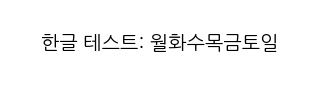

In [ ]:
# eda 1) eda 준
OUTPUT_DIR = "/content/drive/MyDrive/processed/"

df_5min = pd.read_parquet(f"{OUTPUT_DIR}rtu_resampled_5min.parquet")
print("5분 리샘플 데이터:", df_5min.shape)
print(df_5min['module(equipment)'].unique())

# Colab 한글 폰트
!apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# 폰트 점검
mpl_cache_dir = mpl.get_cachedir()
import shutil, os
if os.path.exists(mpl_cache_dir):
    shutil.rmtree(mpl_cache_dir)

font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

print(f"적용된 폰트 이름: {font_name}")
print(f"폰트 파일 경로: {font_path}")

fig_test, ax_test = plt.subplots(figsize=(4, 1))
ax_test.text(0.1, 0.5, '한글 테스트: 월화수목금토일', fontsize=14)
ax_test.axis('off')
plt.show()

In [ ]:
# eda 2) 시간 파생변수 추가

PEAK_HOURS = list(range(21, 24)) + [0]
WEEKDAY_NAMES = ['월', '화', '수', '목', '금', '토', '일']

df_5min['hour'] = df_5min['datetime'].dt.hour
df_5min['dayofweek'] = df_5min['datetime'].dt.dayofweek
df_5min['weekday_name'] = df_5min['dayofweek'].map(lambda x: WEEKDAY_NAMES[x])
df_5min['is_weekend'] = df_5min['dayofweek'].isin([5, 6])
df_5min['is_peak'] = df_5min['hour'].isin(PEAK_HOURS)

heatmap_data 인덱스: ['월', '화', '수', '목', '금', '토', '일']
각 문자 유니코드 확인: [['0xc6d4'], ['0xd654'], ['0xc218'], ['0xbaa9'], ['0xae08'], ['0xd1a0'], ['0xc77c']]


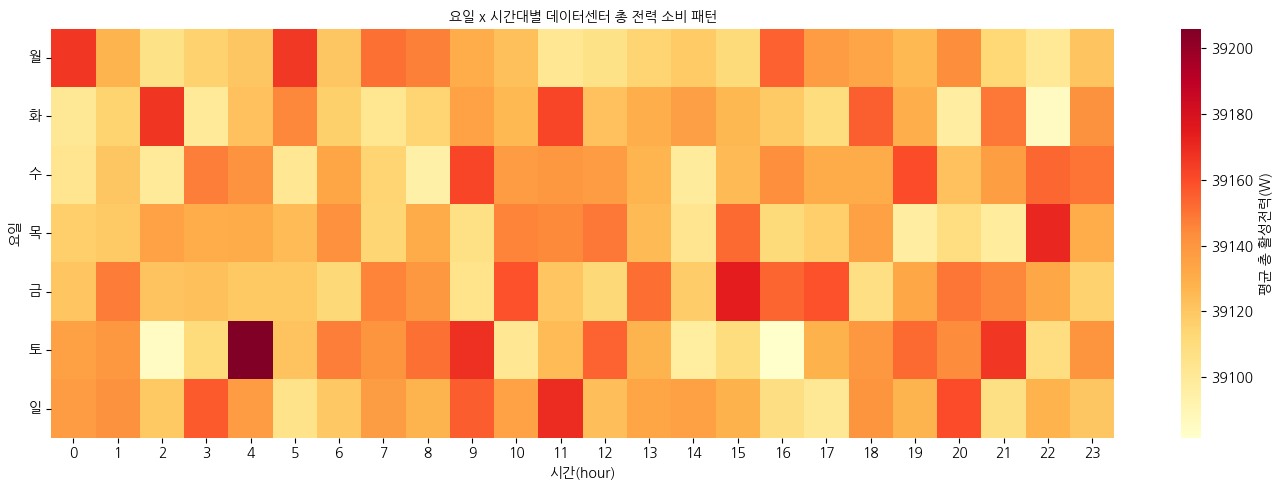

=== 시간대별 평균 총 전력 (요일 무관) ===
hour
4     39139.421875
11    39137.687500
9     39137.617188
18    39134.968750
10    39132.429688
20    39132.250000
15    39132.195312
19    39132.035156
23    39131.199219
21    39130.699219
Name: activePower, dtype: float32


In [ ]:
# eda 3) 시간대 x 요일 히트맵 - 전체 설비 합산 전력 패턴

# 전체 데이터센터 총 소비전력 = 모든 설비 activePower 합산 (같은 시각 기준)
total_power = (
    df_5min.groupby('datetime')['activePower'].sum()
    .reset_index()
)
total_power['hour'] = total_power['datetime'].dt.hour
total_power['dayofweek'] = total_power['datetime'].dt.dayofweek
total_power['weekday_name'] = total_power['dayofweek'].map(lambda x: WEEKDAY_NAMES[x])

heatmap_data = total_power.pivot_table(
    index='weekday_name', columns='hour', values='activePower', aggfunc='mean'
).reindex(WEEKDAY_NAMES)

######코드 점검용####
# 검증: 실제 인덱스 값이 의도한 대로 들어있는지 확인
print("heatmap_data 인덱스:", list(heatmap_data.index))
print("각 문자 유니코드 확인:", [[hex(ord(c)) for c in s] for s in heatmap_data.index])

plt.figure(figsize=(14, 5))
ax = sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, cbar_kws={'label': '평균 총 활성전력(W)'})

korean_font = fm.FontProperties(fname=font_path)
ax.set_yticklabels(heatmap_data.index, fontproperties=korean_font, rotation=0)
ax.set_title('요일 x 시간대별 데이터센터 총 전력 소비 패턴', fontproperties=korean_font)
ax.set_xlabel('시간(hour)', fontproperties=korean_font)
ax.set_ylabel('요일', fontproperties=korean_font)
######코드 점검용######

plt.tight_layout()
plt.savefig('/content/eda_heatmap_power.png', dpi=150)
plt.show()

print("=== 시간대별 평균 총 전력 (요일 무관) ===")
print(total_power.groupby('hour')['activePower'].mean().sort_values(ascending=False).head(10))

=== 피크 vs 비피크 시간대 비교 ===
            powerfactor_avg  reactive_to_active_ratio  voltage_unbalance_pct  \
is_peak                                                                        
비피크               92.468880                  0.199989               2.326166   
피크(21~24시)        92.471024                  0.199976               2.325677   

            current_unbalance_pct  activePower  
is_peak                                         
비피크                     74.807907  3009.967041  
피크(21~24시)              74.795570  3009.876221  


/tmp/ipykernel_1108/3017967679.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['비피크', '피크(21~24시)'])
/tmp/ipykernel_1108/3017967679.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['비피크', '피크(21~24시)'])


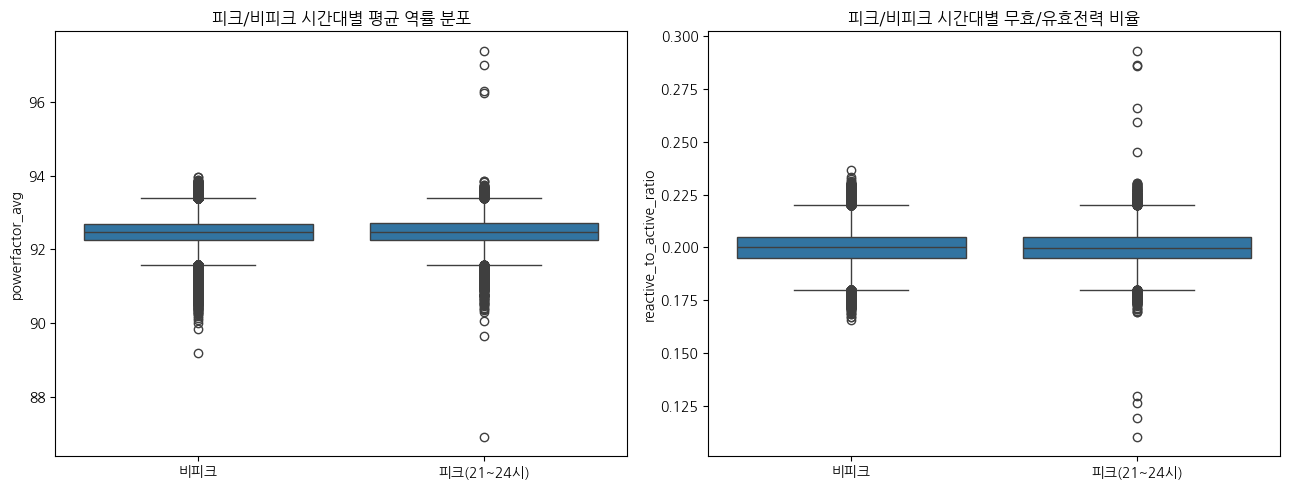

In [ ]:
# eda 4) 피크시간대(21~24시) vs 비피크 - 역률/무효전력비율 비교

peak_compare = df_5min.groupby('is_peak').agg(
    powerfactor_avg=('powerfactor_avg', 'mean'),
    reactive_to_active_ratio=('reactive_to_active_ratio', 'mean'),
    voltage_unbalance_pct=('voltage_unbalance_pct', 'mean'),
    current_unbalance_pct=('current_unbalance_pct', 'mean'),
    activePower=('activePower', 'mean'),
).rename(index={True: '피크(21~24시)', False: '비피크'})

print("=== 피크 vs 비피크 시간대 비교 ===")
print(peak_compare)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_5min, x='is_peak', y='powerfactor_avg', ax=axes[0])
axes[0].set_xticklabels(['비피크', '피크(21~24시)'])
axes[0].set_title('피크/비피크 시간대별 평균 역률 분포')
axes[0].set_xlabel('')

sns.boxplot(data=df_5min, x='is_peak', y='reactive_to_active_ratio', ax=axes[1])
axes[1].set_xticklabels(['비피크', '피크(21~24시)'])
axes[1].set_title('피크/비피크 시간대별 무효/유효전력 비율')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('/content/eda_peak_comparison.png', dpi=150)
plt.show()

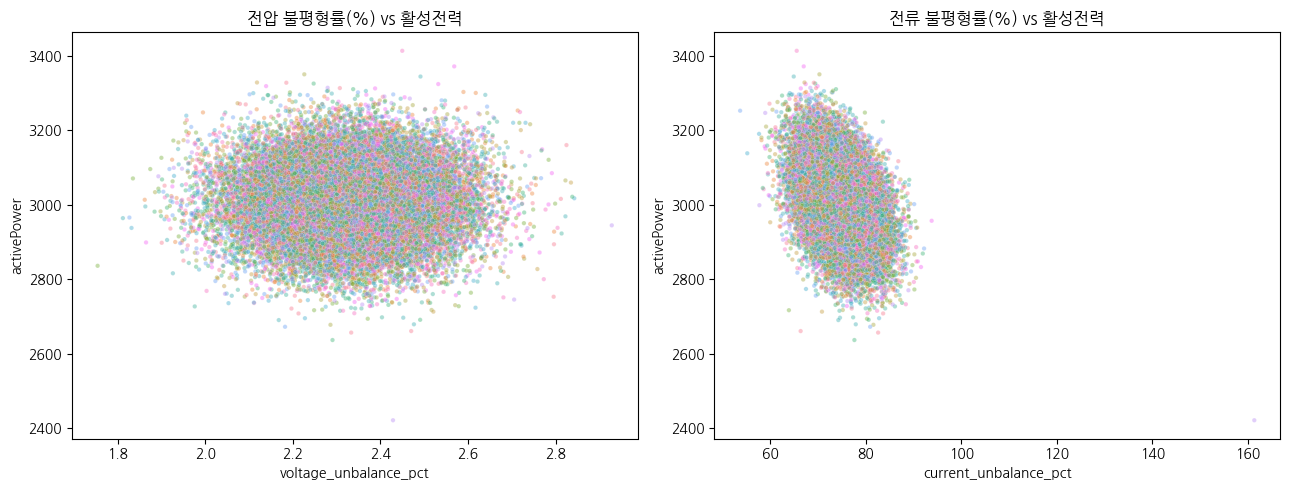

=== 설비별 평균 불평형률 ===
                   voltage_unbalance_pct  current_unbalance_pct
module(equipment)                                              
11(우측분전반1)                      2.326119              74.824516
14(2호기)                         2.326009              74.820084
17(6호기)                         2.326050              74.818977
18(우측분전반2)                      2.325110              74.817955
13(3호기)                         2.331553              74.811592
12(4호기)                         2.325361              74.811447
3(분쇄기(2))                       2.326127              74.808708
16(호이스트)                        2.324433              74.808296
15(예비건조기)                       2.326280              74.801193
2(L-1전등)                        2.324768              74.794060
4(분쇄기(1))                       2.325704              74.792877
1(PM-3)                         2.326201              74.790009
5(좌측분전반)                        2.325392              74.776321


In [ ]:
# eda 5) 3상 불평형도와 전력의 관계
# 설비 스케일이 다 다르므로 설비별 색상 구분, 샘플링해서 과밀 방지
sample_df = df_5min.sample(min(30000, len(df_5min)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=sample_df, x='voltage_unbalance_pct', y='activePower',
    hue='module(equipment)', alpha=0.4, s=10, legend=False, ax=axes[0]
)
axes[0].set_title('전압 불평형률(%) vs 활성전력')

sns.scatterplot(
    data=sample_df, x='current_unbalance_pct', y='activePower',
    hue='module(equipment)', alpha=0.4, s=10, legend=False, ax=axes[1]
)
axes[1].set_title('전류 불평형률(%) vs 활성전력')

plt.tight_layout()
plt.savefig('/content/eda_unbalance_vs_power.png', dpi=150)
plt.show()

print("=== 설비별 평균 불평형률 ===")
print(
    df_5min.groupby('module(equipment)')[['voltage_unbalance_pct', 'current_unbalance_pct']]
    .mean().sort_values('current_unbalance_pct', ascending=False)
)

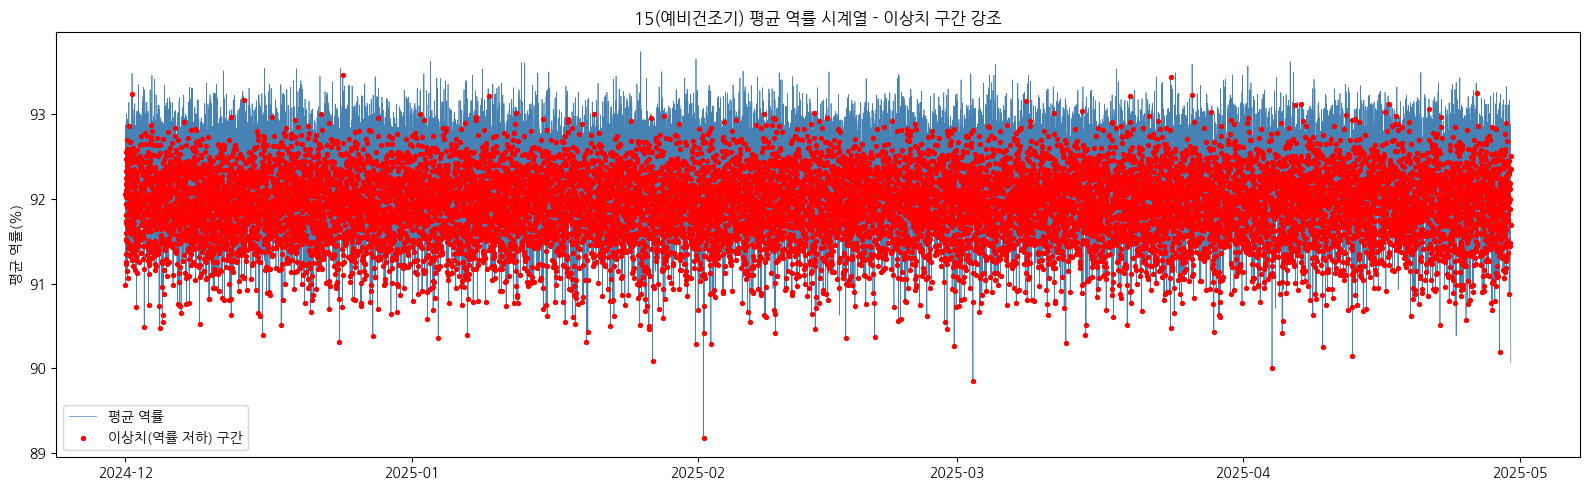

=== 예비건조기 이상치(역률저하) 발생 시간대 분포 ===
hour
0     673
1     704
2     716
3     686
4     689
5     684
6     676
7     672
8     724
9     674
10    674
11    674
12    679
13    694
14    688
15    635
16    691
17    657
18    688
19    651
20    662
21    644
22    695
23    664
Name: count, dtype: int64


In [ ]:
# eda 6) 예비건조기 역률 저하 구간 시계열 시각화
target_eq = '15(예비건조기)'
dryer = df_5min[df_5min['module(equipment)'] == target_eq].sort_values('datetime')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dryer['datetime'], dryer['powerfactor_avg'], linewidth=0.5, color='steelblue', label='평균 역률')

# 통계적 이상치(역률 저하 구간) 강조
outlier_pts = dryer[dryer['is_statistical_outlier'] > 0]
ax.scatter(outlier_pts['datetime'], outlier_pts['powerfactor_avg'],
           color='red', s=8, label='이상치(역률 저하) 구간', zorder=5)

ax.set_title(f'{target_eq} 평균 역률 시계열 - 이상치 구간 강조')
ax.set_ylabel('평균 역률(%)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/eda_dryer_powerfactor_timeline.png', dpi=150)
plt.show()

# 이상치 구간이 특정 요일/시간대에 몰려있는지 재확인 (5분 단위 기준)
dryer['hour'] = dryer['datetime'].dt.hour
print("=== 예비건조기 이상치(역률저하) 발생 시간대 분포 ===")
print(outlier_pts.assign(hour=outlier_pts['datetime'].dt.hour)['hour'].value_counts().sort_index())

=== 설비별 비효율 proxy 요약 (역률 낮은 순) ===
                   avg_powerfactor  avg_reactive_ratio  avg_current_unbalance  \
module(equipment)                                                               
15(예비건조기)                92.247749            0.200026              74.801193   
17(6호기)                  92.349266            0.199997              74.818977   
16(호이스트)                 92.498489            0.199950              74.808296   
2(L-1전등)                 92.498726            0.199999              74.794060   
14(2호기)                  92.498787            0.200010              74.820084   
3(분쇄기(2))                92.498985            0.200044              74.808708   
5(좌측분전반)                 92.499100            0.199958              74.776321   
4(분쇄기(1))                92.500153            0.199993              74.792877   
18(우측분전반2)               92.500847            0.199985              74.817955   
1(PM-3)                  92.500847            0.199896              74.790

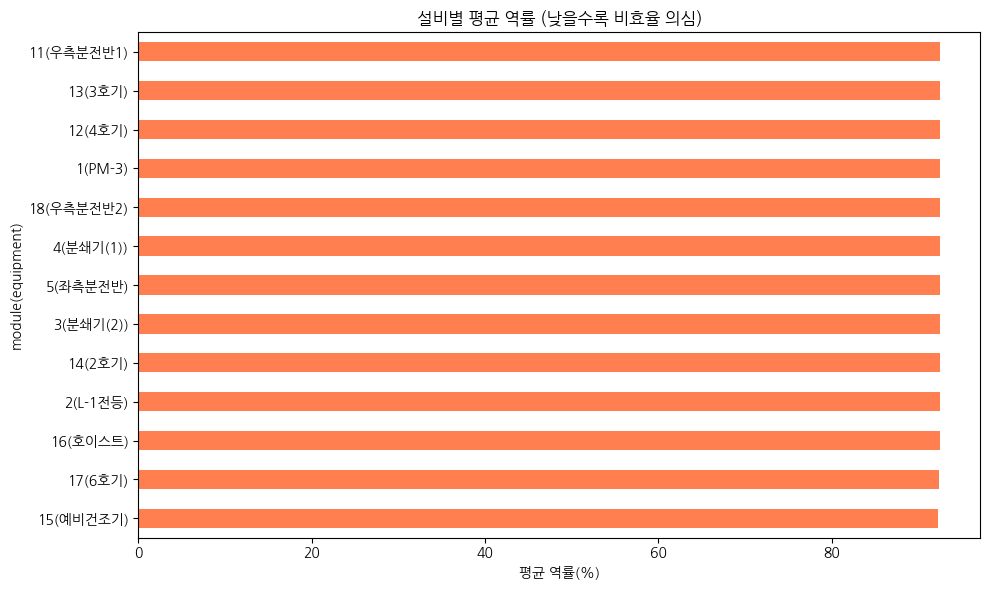

In [ ]:
# eda 7) 설비별 종합 비교 - 비효율 proxy 랭킹
efficiency_summary = df_5min.groupby('module(equipment)').agg(
    avg_powerfactor=('powerfactor_avg', 'mean'),
    avg_reactive_ratio=('reactive_to_active_ratio', 'mean'),
    avg_current_unbalance=('current_unbalance_pct', 'mean'),
    outlier_rate=('is_statistical_outlier', lambda x: (x > 0).mean()),
).sort_values('avg_powerfactor')

print("=== 설비별 비효율 proxy 요약 (역률 낮은 순) ===")
print(efficiency_summary)

fig, ax = plt.subplots(figsize=(10, 6))
efficiency_summary['avg_powerfactor'].sort_values().plot(kind='barh', ax=ax, color='coral')
ax.set_title('설비별 평균 역률 (낮을수록 비효율 의심)')
ax.set_xlabel('평균 역률(%)')
plt.tight_layout()
plt.savefig('/content/eda_equipment_powerfactor_ranking.png', dpi=150)
plt.show()


In [ ]:
# eda 8) 설비 간 차이 통계검정 (ANOVA + eta 제곱)
from scipy import stats

def anova_with_effect_size(df, group_col, value_col):
    groups = [g[value_col].dropna().values for _, g in df.groupby(group_col)]
    f_stat, p_value = stats.f_oneway(*groups)

    grand_mean = df[value_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((df[value_col] - grand_mean) ** 2).sum()
    eta_sq = ss_between / ss_total

    return {
        'variable': value_col,
        'F_statistic': f_stat,
        'p_value': p_value,
        'eta_squared': eta_sq,
    }

test_cols = ['activePower', 'powerfactor_avg', 'voltage_unbalance_pct',
             'current_unbalance_pct', 'reactive_to_active_ratio']

results = [anova_with_effect_size(df_5min, 'module(equipment)', col) for col in test_cols]
results_df = pd.DataFrame(results)

def interpret_eta(x):
    if x < 0.01:
        return '거의 없음'
    elif x < 0.06:
        return '작음'
    elif x < 0.14:
        return '중간'
    else:
        return '큼'

results_df['effect_size_해석'] = results_df['eta_squared'].apply(interpret_eta)

print("=== 설비 간(module(equipment)) 차이 - ANOVA + 효과크기 ===")
print(results_df.to_string(index=False))

print("""
해석 시 참고:
- p_value < 0.05 면 "통계적으로 유의한 차이가 있다"
- 하지만 eta_squared가 0.01 미만이면 그 차이는 실질적으로 무시할 수준
- 즉 p-value는 유의해도 eta_squared가 작으면 "표본이 커서 유의하게 나온 것"으로 해석
""")

# 예비건조기만 제외했을 때 powerfactor_avg 차이가 사라지는지 확인
df_excl_dryer = df_5min[df_5min['module(equipment)'] != '15(예비건조기)']
result_excl = anova_with_effect_size(df_excl_dryer, 'module(equipment)', 'powerfactor_avg')
print("=== 예비건조기 제외 후 powerfactor_avg ANOVA ===")
print(result_excl)

=== 설비 간(module(equipment)) 차이 - ANOVA + 효과크기 ===
                variable  F_statistic      p_value  eta_squared effect_size_해석
             activePower     1.240816 2.475221e-01     0.000027          거의 없음
         powerfactor_avg  2316.250000 0.000000e+00     0.047156             작음
   voltage_unbalance_pct     7.272345 1.669363e-13     0.000155          거의 없음
   current_unbalance_pct     0.412219 9.597372e-01     0.000009          거의 없음
reactive_to_active_ratio     1.058093 3.914367e-01     0.000023          거의 없음

해석 시 참고:
- p_value < 0.05 면 "통계적으로 유의한 차이가 있다"
- 하지만 eta_squared가 0.01 미만이면 그 차이는 실질적으로 무시할 수준
- 즉 p-value는 유의해도 eta_squared가 작으면 "표본이 커서 유의하게 나온 것"으로 해석

=== 예비건조기 제외 후 powerfactor_avg ANOVA ===
{'variable': 'powerfactor_avg', 'F_statistic': np.float32(765.86884), 'p_value': np.float32(0.0), 'eta_squared': np.float32(0.015990727)}


In [ ]:
# eda 9) 전체 피크 유무 확인 검정
hourly_groups = [g['activePower'].dropna().values for _, g in df_5min.groupby('hour')]
f_stat_hour, p_value_hour = stats.f_oneway(*hourly_groups)

grand_mean_hour = df_5min['activePower'].mean()
ss_between_hour = sum(len(g) * (g.mean() - grand_mean_hour) ** 2 for g in hourly_groups)
ss_total_hour = ((df_5min['activePower'] - grand_mean_hour) ** 2).sum()
eta_sq_hour = ss_between_hour / ss_total_hour

print("=== 시간대(0~23시) 전체에 대한 ANOVA (특정 구간 가정 없음) ===")
print(f"F={f_stat_hour:.4f}, p={p_value_hour:.6e}, eta_squared={eta_sq_hour:.6f}")
print(f"효과크기 해석: {interpret_eta(eta_sq_hour)}")

# 시간대별 평균 전력의 실제 변동폭(최대-최소)이 전체 평균 대비 몇 %인지 확인
hourly_mean = df_5min.groupby('hour')['activePower'].mean()
variation_pct = (hourly_mean.max() - hourly_mean.min()) / hourly_mean.mean() * 100
print(f"\n시간대별 평균 activePower 최대-최소 변동폭: {variation_pct:.3f}%")
print(f"가장 높은 시간대: {hourly_mean.idxmax()}시 ({hourly_mean.max():.1f}W)")
print(f"가장 낮은 시간대: {hourly_mean.idxmin()}시 ({hourly_mean.min():.1f}W)")


=== 시간대(0~23시) 전체에 대한 ANOVA (특정 구간 가정 없음) ===
F=0.4777, p=9.833278e-01, eta_squared=0.000020
효과크기 해석: 거의 없음

시간대별 평균 activePower 최대-최소 변동폭: 0.061%
가장 높은 시간대: 4시 (3010.7W)
가장 낮은 시간대: 14시 (3008.9W)


상위 5% 임계값: 39678.8W / 하위 5% 임계값: 38575.6W
상위 5% 구간 수: 2,161 / 하위 5% 구간 수: 2,161

=== 상위 5% 구간 - 요일별 분포 ===
weekday_name
일    334
목    325
화    314
금    304
수    302
월    294
토    288
Name: count, dtype: int64

=== 하위 5% 구간 - 요일별 분포 ===
weekday_name
목    350
화    320
월    312
금    311
일    301
토    292
수    275
Name: count, dtype: int64

=== 상위 5% 구간 - 시간대별 분포 ===
hour
0      93
1      91
2      84
3      83
4     107
5      86
6      80
7      94
8      83
9      95
10     98
11     99
12     81
13     87
14     87
15     88
16     92
17     97
18     92
19     93
20     90
21     99
22     88
23     74
Name: count, dtype: int64

=== 하위 5% 구간 - 시간대별 분포 ===
hour
0     104
1      90
2      83
3      90
4      83
5     100
6      81
7      79
8      96
9     101
10     83
11     89
12    100
13     66
14    117
15     96
16     72
17    101
18     83
19     82
20     91
21     88
22     90
23     96
Name: count, dtype: int64

=== 모든 토요일 4시대(00~59분) activePower (252개 구간) ===
           dat

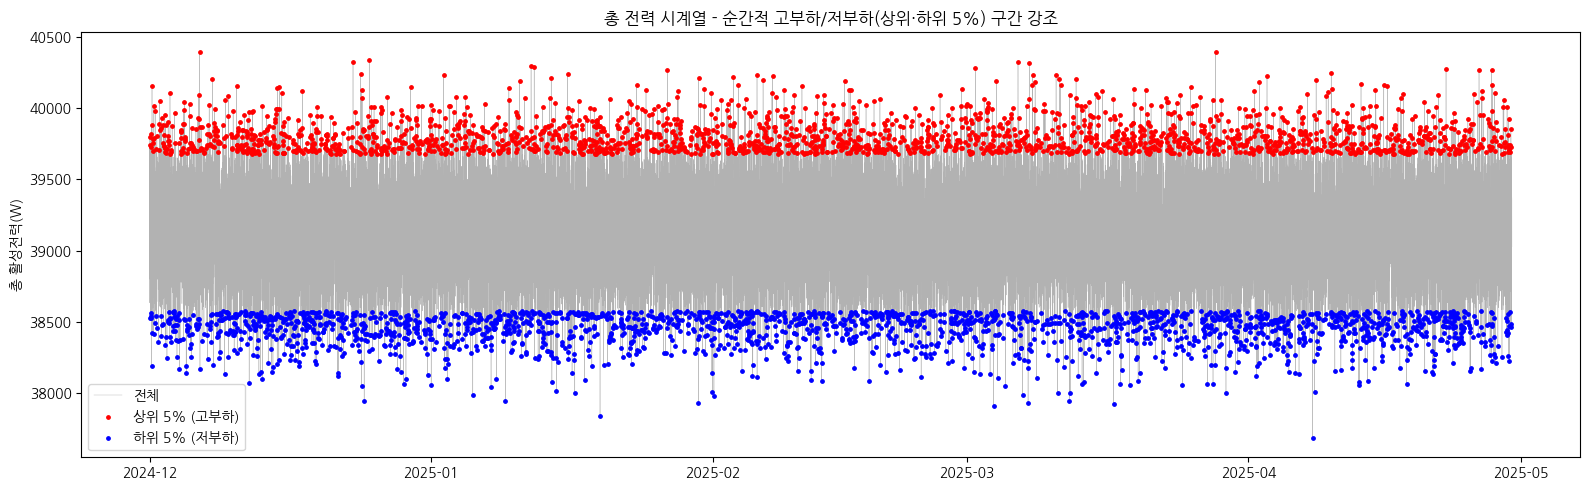

In [ ]:
# eda 10)
top5_threshold = total_power['activePower'].quantile(0.95)
bottom5_threshold = total_power['activePower'].quantile(0.05)

top5 = total_power[total_power['activePower'] >= top5_threshold]
bottom5 = total_power[total_power['activePower'] <= bottom5_threshold]

print(f"상위 5% 임계값: {top5_threshold:.1f}W / 하위 5% 임계값: {bottom5_threshold:.1f}W")
print(f"상위 5% 구간 수: {len(top5):,} / 하위 5% 구간 수: {len(bottom5):,}")

print("\n=== 상위 5% 구간 - 요일별 분포 ===")
print(top5['weekday_name'].value_counts())
print("\n=== 하위 5% 구간 - 요일별 분포 ===")
print(bottom5['weekday_name'].value_counts())

print("\n=== 상위 5% 구간 - 시간대별 분포 ===")
print(top5['hour'].value_counts().sort_index())
print("\n=== 하위 5% 구간 - 시간대별 분포 ===")
print(bottom5['hour'].value_counts().sort_index())

# 히트맵에서 튀었던 "토요일 4시" 특이점 - 반복되는 패턴인지, 우연 1회성인지 확인
sat_4am = total_power[(total_power['weekday_name'] == '토') & (total_power['hour'] == 4)]
print(f"\n=== 모든 토요일 4시대(00~59분) activePower ({len(sat_4am)}개 구간) ===")
print(sat_4am[['datetime', 'activePower']].to_string(index=False))
print(f"\n토요일 4시대 평균: {sat_4am['activePower'].mean():.1f}W")
print(f"전체 평균: {total_power['activePower'].mean():.1f}W")
print(f"토요일 4시대 표준편차: {sat_4am['activePower'].std():.1f}W (변동이 크면 그날만의 우연일 가능성)")

# 시계열에 상위/하위 5% 구간 강조해서 시각화
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(total_power['datetime'], total_power['activePower'], linewidth=0.3, color='gray', alpha=0.6, label='전체')
ax.scatter(top5['datetime'], top5['activePower'], color='red', s=6, label='상위 5% (고부하)', zorder=5)
ax.scatter(bottom5['datetime'], bottom5['activePower'], color='blue', s=6, label='하위 5% (저부하)', zorder=5)
ax.set_title('총 전력 시계열 - 순간적 고부하/저부하(상위·하위 5%) 구간 강조')
ax.set_ylabel('총 활성전력(W)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/eda_extreme_load_timeline.png', dpi=150)
plt.show()


=== 월별 총 전력 평균/표준편차 ===
                 mean         std
month                            
2024-12  39125.421875  334.136780
2025-01  39130.378906  334.167511
2025-02  39133.113281  332.876221
2025-03  39130.132812  335.237854
2025-04  39128.109375  334.187988

=== 설비별 월별 평균 역률 ===
module(equipment)    1(PM-3)  11(우측분전반1)    12(4호기)    13(3호기)    14(2호기)  \
month                                                                       
2024-12            92.498001   92.505997  92.504997  92.510002  92.501999   
2025-01            92.495003   92.500999  92.500999  92.501999  92.495003   
2025-02            92.503998   92.502998  92.500000  92.500000  92.498001   
2025-03            92.502998   92.508003  92.498001  92.499001  92.500000   
2025-04            92.503998   92.501999  92.500999  92.498001  92.499001   

module(equipment)  15(예비건조기)   16(호이스트)    17(6호기)  18(우측분전반2)   2(L-1전등)  \
month                                                                       
2024-12            92.

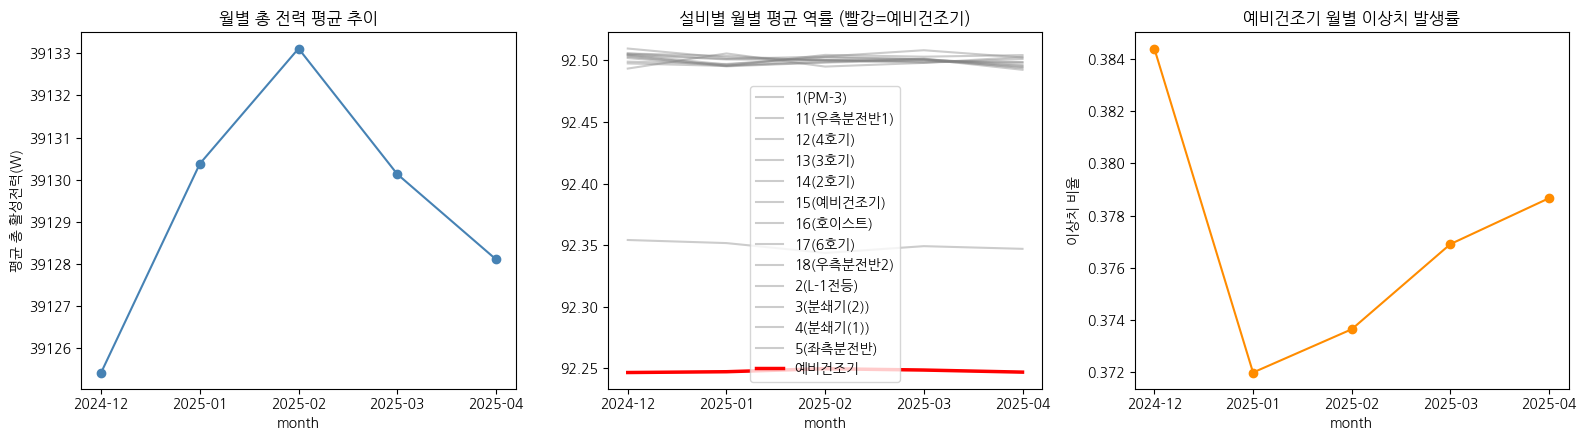

In [ ]:
# eda 11)
df_5min['month'] = df_5min['datetime'].dt.to_period('M').astype(str)
total_power['month'] = total_power['datetime'].dt.to_period('M').astype(str)

# (1) 전체 총 전력의 월별 평균 추이
monthly_total_power = total_power.groupby('month')['activePower'].agg(['mean', 'std'])
print("=== 월별 총 전력 평균/표준편차 ===")
print(monthly_total_power)

# (2) 설비별 월별 평균 역률 추이 (예비건조기 vs 나머지 비교)
monthly_pf = df_5min.groupby(['month', 'module(equipment)'])['powerfactor_avg'].mean().reset_index()
monthly_pf_pivot = monthly_pf.pivot(index='month', columns='module(equipment)', values='powerfactor_avg')
print("\n=== 설비별 월별 평균 역률 ===")
print(monthly_pf_pivot.round(3))

# (3) 예비건조기의 이상치 발생률이 달 지날수록 늘어나는지(=노후화 신호) 확인
dryer_monthly = df_5min[df_5min['module(equipment)'] == '15(예비건조기)'].groupby('month').agg(
    powerfactor_avg=('powerfactor_avg', 'mean'),
    outlier_rate=('is_statistical_outlier', lambda x: (x > 0).mean())
)
print("\n=== 예비건조기 월별 역률·이상치율 추이 (노후화 신호 확인용) ===")
print(dryer_monthly)

# 시각화: 전체 총전력 + 예비건조기 역률 월별 추이를 나란히
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

monthly_total_power['mean'].plot(kind='line', marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('월별 총 전력 평균 추이')
axes[0].set_ylabel('평균 총 활성전력(W)')

monthly_pf_pivot.plot(ax=axes[1], legend=False, alpha=0.4, color='gray')
monthly_pf_pivot['15(예비건조기)'].plot(ax=axes[1], color='red', linewidth=2.5, label='예비건조기')
axes[1].set_title('설비별 월별 평균 역률 (빨강=예비건조기)')
axes[1].legend()

dryer_monthly['outlier_rate'].plot(kind='line', marker='o', ax=axes[2], color='darkorange')
axes[2].set_title('예비건조기 월별 이상치 발생률')
axes[2].set_ylabel('이상치 비율')

plt.tight_layout()
plt.savefig('/content/eda_monthly_trend.png', dpi=150)
plt.show()

In [ ]:
# eda 12)
dryer_df = df_5min[df_5min['module(equipment)'] == '15(예비건조기)'][['datetime', 'is_statistical_outlier']]
dryer_outlier_times = set(dryer_df[dryer_df['is_statistical_outlier'] > 0]['datetime'])
dryer_normal_times = set(dryer_df[dryer_df['is_statistical_outlier'] == 0]['datetime'])

other_equip = df_5min[df_5min['module(equipment)'] != '15(예비건조기)']

other_during_outlier = other_equip[other_equip['datetime'].isin(dryer_outlier_times)]
other_during_normal = other_equip[other_equip['datetime'].isin(dryer_normal_times)]

print("=== 예비건조기 이상치 발생 시점 vs 정상 시점 - 다른 설비들 비교 ===")
compare_cols = ['powerfactor_avg', 'activePower', 'voltage_unbalance_pct', 'current_unbalance_pct']
comparison = pd.DataFrame({
    '이상치 시점(다른 설비)': other_during_outlier[compare_cols].mean(),
    '정상 시점(다른 설비)': other_during_normal[compare_cols].mean(),
})
comparison['차이(%)'] = (comparison['이상치 시점(다른 설비)'] - comparison['정상 시점(다른 설비)']) / comparison['정상 시점(다른 설비)'] * 100
print(comparison)

# 통계검정: 이상치 시점 vs 정상 시점, 다른 설비들의 powerfactor_avg가 정말 다른지
t_stat, p_val = stats.ttest_ind(
    other_during_outlier['powerfactor_avg'].dropna(),
    other_during_normal['powerfactor_avg'].dropna(),
    equal_var=False
)
print(f"\n다른 설비 powerfactor_avg - t검정: t={t_stat:.4f}, p={p_val:.6f}")
print("(p<0.05면 '같이 흔들린다'는 근거, p>=0.05면 '예비건조기만 단독으로 흔들린다'는 근거)")

# 설비별로 개별 확인 (특정 설비 하나만 같이 흔들릴 수도 있으니)
print("\n=== 설비별 개별 확인 (이상치 시점 vs 정상 시점 역률 차이) ===")
for eq in other_equip['module(equipment)'].unique():
    eq_outlier = other_during_outlier[other_during_outlier['module(equipment)'] == eq]['powerfactor_avg']
    eq_normal = other_during_normal[other_during_normal['module(equipment)'] == eq]['powerfactor_avg']
    if len(eq_outlier) > 30 and len(eq_normal) > 30:
        t, p = stats.ttest_ind(eq_outlier.dropna(), eq_normal.dropna(), equal_var=False)
        diff = eq_outlier.mean() - eq_normal.mean()
        print(f"{eq:15s}: 차이={diff:+.4f}, p={p:.4f} {'★유의함' if p < 0.05 else ''}")


=== 예비건조기 이상치 발생 시점 vs 정상 시점 - 다른 설비들 비교 ===
                       이상치 시점(다른 설비)  정상 시점(다른 설비)     차이(%)
powerfactor_avg            92.487984     92.487534  0.000487
activePower              3010.058105   3009.832520  0.007495
voltage_unbalance_pct       2.325985      2.326119 -0.005760
current_unbalance_pct      74.811325     74.803154  0.010923

다른 설비 powerfactor_avg - t검정: t=0.4760, p=0.634088
(p<0.05면 '같이 흔들린다'는 근거, p>=0.05면 '예비건조기만 단독으로 흔들린다'는 근거)

=== 설비별 개별 확인 (이상치 시점 vs 정상 시점 역률 차이) ===
1(PM-3)        : 차이=+0.0003, p=0.9375 
11(우측분전반1)     : 차이=-0.0005, p=0.8696 
12(4호기)        : 차이=-0.0003, p=0.9372 
13(3호기)        : 차이=+0.0002, p=0.9602 
14(2호기)        : 차이=+0.0013, p=0.6757 
16(호이스트)       : 차이=-0.0027, p=0.4021 
17(6호기)        : 차이=+0.0012, p=0.7502 
18(우측분전반2)     : 차이=+0.0015, p=0.6323 
2(L-1전등)       : 차이=+0.0049, p=0.1223 
3(분쇄기(2))      : 차이=+0.0040, p=0.2085 
4(분쇄기(1))      : 차이=-0.0033, p=0.2943 
5(좌측분전반)       : 차이=-0.0010, p=0.7495 



<eda 결론>

1.   시간대별 전력 패턴이 존재하지 않음  

p-value가 0.983으로 시간대 간에 차이가 있다고 볼 수 없음을 의미함. 따라서 피크 시간대는 없으며 결과에 나온 피크는 그냥 노이즈임.(4번 eda에서 임의의 시간대인 오후 10시 전후가 피크라고 가정해서 검정했으나 이 또한 기각되어서 추가로 검정한 것임)    
 또한 3번 eda 히트맵 결과를 바탕으로 토요일 4시에 특정한 전력 패턴(피크 여부)가 있는지를 10번 eda에서 확인한 결과, 특정 패턴이 없다고 나옴.

 cf) 상위/하위 5% 요일/시간대별로 총 4개를 확인해보았지만 차이가 없는 것으로 결과가 나옴  
계절(월별)에 따라 트렌트 유무를 파악하기 위해 11번 eda, 15번 설비 이상 시점에 다른 설비도 같이 흔들리는지 상관관계를 확인하기 위해 12번 eda를 진행했으나 해당 가설들이 모두 기각되었음.

2.   설비 종류가 달라져도 전력 패턴이 유사함  

activepower가 조명회로, 분쇄기, 호이스트등의 다른 설비 간에도 전부 2,800~3,400W구간에 몰려있었음.


3.   예비건조기 설비만 역률이 움직임

해당 설비를 통계검정에서 제외시, eta^2가 (설비간 역률 차이) 0.047에서 0.016으로 감소함. 따라서 역률 차이의 상당 부분이 해당 설비 때문이라고 볼 수 있음.

